# Laboratorio 6: centralidad, sentimiento y conclusiones

Este notebook desarrolla los ejercicios 8, 9 y 10 a partir de la red bipartita autor–video y sus dos proyecciones, construidas en `01_preparacion_y_red_bipartita.ipynb` y `02_proyecciones_topologia_y_comunidades.ipynb`. El notebook es autosuficiente: recarga los datos procesados y reconstruye la red y las comunidades desde los archivos en `data_processed/` y `output/`, sin depender de variables en memoria de los notebooks anteriores.

## Preparación

Se repite, sin modificaciones, la reconstrucción de la red bipartita, las proyecciones y la partición de comunidades que ya se validó en `02_proyecciones_topologia_y_comunidades.ipynb` (351 nodos, 343 aristas, 12 comunidades, modularidad ponderada 0.4053). Es la misma cadena, no una versión distinta: mantenerla idéntica es lo que permite comparar los resultados de centralidad y sentimiento con los de las secciones anteriores.

In [1]:
from pathlib import Path
from collections import Counter
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display
from networkx.algorithms import bipartite
from networkx.algorithms.community import louvain_communities, modularity
from sklearn.metrics import classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 90)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def encontrar_raiz():
    candidatos = [Path.cwd(), Path.cwd().parent]
    for candidato in candidatos:
        if (candidato / 'data_processed' / 'youtube_comments_processed.csv').exists():
            return candidato
    raise FileNotFoundError('No se encontró la carpeta del laboratorio con los datos procesados.')

RAIZ = encontrar_raiz()
comments = pd.read_csv(RAIZ / 'data_processed' / 'youtube_comments_processed.csv')
videos = pd.read_csv(RAIZ / 'data_processed' / 'youtube_videos_processed.csv')
tabla_nodos = pd.read_csv(RAIZ / 'output' / 'tabla_nodos.csv')
tabla_aristas = pd.read_csv(RAIZ / 'output' / 'tabla_aristas.csv')

print(f'Comentarios procesados: {len(comments):,}')
print(f'Videos disponibles: {len(videos):,}')
print(f'Nodos con participación: {len(tabla_nodos):,}')
print(f'Aristas autor–video: {len(tabla_aristas):,}')

Comentarios procesados: 406
Videos disponibles: 293
Nodos con participación: 351
Aristas autor–video: 343


In [3]:
red_bipartita = nx.Graph(nombre='Red bipartita autor-video')

for fila in tabla_nodos.to_dict('records'):
    atributos = {k: v for k, v in fila.items() if k != 'node_id' and pd.notna(v)}
    atributos['bipartite'] = 0 if fila['tipo'] == 'autor' else 1
    red_bipartita.add_node(fila['node_id'], **atributos)

for fila in tabla_aristas.to_dict('records'):
    red_bipartita.add_edge(fila['source'], fila['target'], weight=int(fila['peso']))

autores = [n for n, d in red_bipartita.nodes(data=True) if d['tipo'] == 'autor']
videos_red = [n for n, d in red_bipartita.nodes(data=True) if d['tipo'] == 'video']

assert bipartite.is_bipartite(red_bipartita)
assert red_bipartita.number_of_edges() == len(tabla_aristas)
assert sum(d['weight'] for _, _, d in red_bipartita.edges(data=True)) == len(comments)
print(f'Red validada: {len(autores)} autores, {len(videos_red)} videos y {red_bipartita.number_of_edges()} relaciones únicas.')

Red validada: 332 autores, 19 videos y 343 relaciones únicas.


In [4]:
proyeccion_autores = bipartite.weighted_projected_graph(red_bipartita, autores, ratio=False)
proyeccion_videos = bipartite.weighted_projected_graph(red_bipartita, videos_red, ratio=False)

print(f'Proyección autor–autor: {proyeccion_autores.number_of_nodes()} nodos, {proyeccion_autores.number_of_edges()} aristas.')
print(f'Proyección video–video: {proyeccion_videos.number_of_nodes()} nodos, {proyeccion_videos.number_of_edges()} aristas.')

Proyección autor–autor: 332 nodos, 10732 aristas.
Proyección video–video: 19 nodos, 11 aristas.


In [5]:
comunidades = louvain_communities(
    proyeccion_videos, weight='weight', resolution=1, seed=42
)
comunidades = sorted(comunidades, key=len, reverse=True)
calidad_modularidad = modularity(proyeccion_videos, comunidades, weight='weight')
comunidad_de = {nodo: i + 1 for i, comunidad in enumerate(comunidades) for nodo in comunidad}
nx.set_node_attributes(proyeccion_videos, comunidad_de, 'comunidad')

comments['video_node_id'] = 'video::' + comments['video_id'].astype(str)
comments['comunidad'] = comments['video_node_id'].map(comunidad_de)

print(f'Comunidades detectadas: {len(comunidades)}')
print(f'Modularidad ponderada: {calidad_modularidad:.4f}')

Comunidades detectadas: 12
Modularidad ponderada: 0.4053


# 8. Nodos centrales y participantes puente

Se calculan medidas de centralidad complementarias sobre las tres redes (bipartita, proyección autor–autor y proyección video–video), cada una con una lectura distinta:

- **Grado / fuerza**: cuántas conexiones tiene un nodo y qué tan intensas son (peso). Mide recurrencia directa.
- **Grado de centralidad bipartito** (`bipartite.degree_centrality`): normaliza el grado por el tamaño del conjunto de nodos *opuesto*, la forma correcta de comparar autores y videos en un grafo bipartito (`nx.degree_centrality` estándar normalizaría por `n-1` de toda la red, mezclando ambos tipos de nodo).
- **Intermediación (betweenness)**: la medida central de esta sección, cuántos caminos más cortos entre otros pares de nodos pasan por él. Es la operacionalización directa de "puente".
- **Cercanía (closeness)**: qué tan rápido, en promedio, un nodo alcanza al resto de la red. En un grafo desconectado (esta red tiene 10 componentes) NetworkX aplica automáticamente la corrección de Wasserman–Faust, normalizando por el tamaño del componente alcanzable en vez de por el total de nodos.
- **PageRank**: robusta a la desconexión porque incluye un factor de amortiguación que garantiza convergencia aunque existan componentes aislados.
- **Vector propio**: solo está bien definida dentro de una componente conexa (el teorema de Perron–Frobenius exige una matriz de adyacencia irreducible). Como las tres redes están desconectadas, `eigenvector_centrality_numpy` sobre el grafo completo lanza `AmbiguousSolution`; se calcula entonces solo sobre la componente conexa más grande, y el resto de los nodos queda documentado como `NaN` en vez de forzar un valor sin sustento matemático.

Betweenness y closeness se calculan **sin ponderar** (`weight=None`): un peso alto en esta red significa "más comentarios o vecinos compartidos", es decir, una relación *más fuerte*, no una distancia más larga, usar el peso como longitud de camino invertiría el sentido de la medida. PageRank sí usa el peso, porque en su formulación un peso mayor aumenta el flujo transferido por esa arista, que es la lectura correcta aquí.

En la red bipartita, la distancia mínima entre dos autores es siempre 2 (autor–video–autor), así que las magnitudes de cercanía e intermediación **no son comparables** entre la bipartita y las proyecciones; solo el orden relativo dentro de cada red tiene sentido.

In [6]:
def eigenvector_componente_mayor(G, weight='weight'):
    componentes = sorted(nx.connected_components(G), key=len, reverse=True)
    if not componentes:
        return {n: np.nan for n in G.nodes()}
    mayor = G.subgraph(componentes[0])
    ev_mayor = nx.eigenvector_centrality_numpy(mayor, weight=weight)
    return {n: ev_mayor.get(n, np.nan) for n in G.nodes()}

def calcular_centralidades(G, es_bipartita=False, autores_set=None):
    grado = dict(G.degree())
    grado_ponderado = dict(G.degree(weight='weight'))
    grado_centralidad = (bipartite.degree_centrality(G, autores_set) if es_bipartita
                         else nx.degree_centrality(G))
    intermediacion = nx.betweenness_centrality(G, weight=None, normalized=True)
    cercania = nx.closeness_centrality(G)
    pagerank = nx.pagerank(G, weight='weight')
    vector_propio = eigenvector_componente_mayor(G, weight='weight')
    filas = [{
        'id': n,
        'grado': grado[n],
        'grado_ponderado': grado_ponderado[n],
        'grado_centralidad': grado_centralidad[n],
        'intermediacion': intermediacion[n],
        'cercania': cercania[n],
        'pagerank': pagerank[n],
        'vector_propio': vector_propio[n],
    } for n in G.nodes()]
    return pd.DataFrame(filas).set_index('id')

centralidad_bipartita = calcular_centralidades(red_bipartita, es_bipartita=True, autores_set=autores)
centralidad_autores_proy = calcular_centralidades(proyeccion_autores)
centralidad_videos_proy = calcular_centralidades(proyeccion_videos)

resumen_centralidad = pd.DataFrame([
    {'red': 'Bipartita', **centralidad_bipartita.drop(columns='grado_centralidad').mean(numeric_only=True).to_dict()},
    {'red': 'Autor–autor', **centralidad_autores_proy.drop(columns='grado_centralidad').mean(numeric_only=True).to_dict()},
    {'red': 'Video–video', **centralidad_videos_proy.drop(columns='grado_centralidad').mean(numeric_only=True).to_dict()},
]).set_index('red')
resumen_centralidad.round(4)

,grado,grado_ponderado,intermediacion,cercania,pagerank,vector_propio
red,,,,,,
Bipartita,1.9544,2.3134,0.0071,0.1540,0.0028,0.0276
Autor–autor,64.6506,64.6627,0.0028,0.3198,0.0030,0.0415
Video–video,1.1579,1.3684,0.0230,0.1111,0.0526,0.2579


## 8.2 Autores: recurrencia y diversidad de participación

Se separan dos ejes que no son lo mismo:

- **Recurrencia**: cuántos comentarios publicó un autor (`comentarios`), participación repetida, sin importar dónde.
- **Diversidad**: en cuántos videos distintos participó (`videos_distintos`), en cuántos canales distintos (`canales_distintos`: el canal que publicó cada video comentado, no el canal propio del autor) y en cuántas comunidades de contenido distintas (`comunidades_distintas`).

Un autor puede ser muy recurrente en un solo video (alta frecuencia, baja diversidad) o comentar poco pero en muchos videos distintos (baja frecuencia, alta diversidad). Solo el segundo patrón es compatible con actuar como puente entre contenidos.

In [7]:
autor_stats = comments.groupby('author_channel_id').agg(
    nombre=('author_name', 'first'),
    comentarios=('comment_id', 'size'),
    videos_distintos=('video_id', 'nunique'),
    canales_distintos=('channel_id', 'nunique'),
    comunidades_distintas=('comunidad', 'nunique'),
).reset_index()
autor_stats['node_id'] = 'autor::' + autor_stats['author_channel_id'].astype(str)
autor_stats = autor_stats.set_index('node_id')

centralidad_autores = centralidad_bipartita.loc[autores].join(autor_stats)
centralidad_autores = centralidad_autores.join(centralidad_autores_proy.add_prefix('proy_'), how='left')

print('Top 10 autores por recurrencia (número de comentarios):')
display(centralidad_autores.sort_values('comentarios', ascending=False)
        .head(10)[['nombre', 'comentarios', 'videos_distintos', 'canales_distintos', 'intermediacion']])

print('Top 10 autores por diversidad (videos distintos comentados):')
display(centralidad_autores.sort_values(['videos_distintos', 'comentarios'], ascending=False)
        .head(10)[['nombre', 'videos_distintos', 'canales_distintos', 'comunidades_distintas', 'comentarios', 'intermediacion']])

Top 10 autores por recurrencia (número de comentarios):


,nombre,comentarios,videos_distintos,canales_distintos,intermediacion
id,,,,,
autor::UCi2KiZq63sRq8Mfbcp-MelQ,@eugeneramirez4405,6,1,1,0.000000
autor::UCyJhqmMbsvjpoarBBStA2kg,@Murmullodelbarrio,6,1,1,0.000000
autor::UCV3fr-YOixFKCZBbJP1-X4w,@albertoshernandez5251,5,1,1,0.000000
autor::UC5H8ASmMC9WrURmzeB4ySog,@ManuelEdran,5,1,1,0.000000
autor::UC9vMq1YF-e7C-VO0SHkbUTA,@ErvinLeonardoCarreraLatín,4,1,1,0.000000
autor::UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,4,3,1,0.059705
autor::UCFjudnPLoaSL1BaRuLahyHg,@HaroldoCastillo-rh9iw,3,1,1,0.000000
autor::UC72gBAtyb_VXQlYDcFrh6oQ,@osmanmorales3012,3,1,1,0.000000
autor::UChs3tU2BcKOT0CezykvAsGw,@byronpontaza,3,1,1,0.000000


Top 10 autores por diversidad (videos distintos comentados):


,nombre,videos_distintos,canales_distintos,comunidades_distintas,comentarios,intermediacion
id,,,,,,
autor::UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,3,1,1,4,0.059705
autor::UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,3,1,2,3,0.218076
autor::UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,2,2,2,3,0.231584
autor::UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,2,1,1,3,0.089153
autor::UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,2,2,1,2,0.031862
autor::UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,2,2,1,2,0.057896
autor::UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,2,1,1,2,0.176832
autor::UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,2,1,1,2,0.032296
autor::UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,2,2,1,2,0.031862


## 8.2 Videos: alcance en la red y capacidad de conectar audiencias

Para videos, "alcance" se mide como autores únicos que comentaron (cobertura real de audiencia observada), y "capacidad de conectar audiencias" es lo que capturan el grado y la intermediación en la proyección video–video: un video con muchas aristas hacia otros videos comparte autores con ellos. Se contrasta explícitamente contra `view_count`, que mide visibilidad pasiva, no participación, ya se sabe (Fig. 9 de la campaña de simulación de otro laboratorio no aplica aquí, pero el patrón general de que vistas y participación son cosas distintas es exactamente lo que se prueba a continuación).

In [8]:
video_stats = comments.groupby('video_id').agg(
    comentarios=('comment_id', 'size'),
    autores_unicos=('author_channel_id', 'nunique'),
).reset_index()
video_stats['node_id'] = 'video::' + video_stats['video_id'].astype(str)
video_stats = video_stats.merge(
    videos[['video_id', 'title', 'channel_name', 'category', 'view_count']],
    on='video_id', how='left'
).set_index('node_id')
video_stats['comunidad'] = video_stats.index.map(comunidad_de)

centralidad_videos = centralidad_bipartita.loc[videos_red].join(video_stats)
centralidad_videos = centralidad_videos.join(centralidad_videos_proy.add_prefix('proy_'), how='left')

print('Videos ordenados por alcance en la red (autores únicos):')
display(centralidad_videos.sort_values('autores_unicos', ascending=False)
        [['title', 'channel_name', 'autores_unicos', 'view_count', 'intermediacion', 'proy_grado']])

correlacion_alcance_visibilidad = centralidad_videos[['autores_unicos', 'view_count']].corr(method='spearman').iloc[0, 1]
print(f'Correlación de Spearman entre alcance (autores únicos) y visibilidad (view_count): {correlacion_alcance_visibilidad:.3f}.')

Videos ordenados por alcance en la red (autores únicos):


,title,channel_name,autores_unicos,view_count,intermediacion,proy_grado
id,,,,,,
video::n8iP75gIpmw,Qué rico come tu diputado,Quorum,128,11775,0.565698,4
video::j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,49,10156,0.227474,3
video::6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,32,11670,0.187622,2
video::lj983NWyAQY,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,304089,0.004912,0
video::PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,19,3628,0.244028,2
video::OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticia...,Noticias Telemundo,18,14200,0.002505,0
video::yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,Quorum,16,1954,0.063668,2
video::06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,13,6692,0.054720,1
video::ndAZjHqzzT8,Internet: escoger el menos malo,Quorum,10,717,0.128293,4


Correlación de Spearman entre alcance (autores únicos) y visibilidad (view_count): 0.812.


## 8.3 Puentes y articuladores

Un **punto de articulación** es, por definición, un nodo cuya eliminación aumenta el número de componentes conexos de la red: es la operacionalización exacta de "si lo elimináramos, la red se segmenta". Se calculan sobre la red bipartita completa (en la proyección autor–autor la densidad es demasiado alta y en video–video la red es demasiado pequeña para que la remoción de un solo nodo sea informativa). Se complementa con **puentes** (`nx.bridges`): aristas cuya eliminación desconecta la red, el equivalente a nivel de relación individual.

In [9]:
puntos_articulacion = list(nx.articulation_points(red_bipartita))
puentes = list(nx.bridges(red_bipartita))
componentes_originales = nx.number_connected_components(red_bipartita)
tamano_mayor_original = len(max(nx.connected_components(red_bipartita), key=len))

filas_impacto = []
for nodo in puntos_articulacion:
    G_temp = red_bipartita.copy()
    G_temp.remove_node(nodo)
    componentes_nuevos = nx.number_connected_components(G_temp)
    tamano_mayor_nuevo = len(max(nx.connected_components(G_temp), key=len)) if G_temp.number_of_nodes() else 0
    tipo = red_bipartita.nodes[nodo].get('tipo', '')
    filas_impacto.append({
        'id': nodo,
        'nombre': red_bipartita.nodes[nodo].get('nombre', nodo),
        'tipo': tipo,
        'incremento_componentes': componentes_nuevos - componentes_originales,
        'reduccion_componente_mayor': tamano_mayor_original - tamano_mayor_nuevo,
        'intermediacion': centralidad_bipartita.loc[nodo, 'intermediacion'],
        'videos_distintos': autor_stats['videos_distintos'].get(nodo, np.nan) if tipo == 'autor' else np.nan,
    })
tabla_articuladores = pd.DataFrame(filas_impacto).sort_values('incremento_componentes', ascending=False)

print(f'Puntos de articulación: {len(puntos_articulacion)} de {red_bipartita.number_of_nodes()} nodos.')
print(f'Puentes (aristas críticas): {len(puentes)} de {red_bipartita.number_of_edges()} aristas.')
tabla_articuladores.head(15)

Puntos de articulación: 22 de 351 nodos.
Puentes (aristas críticas): 335 de 343 aristas.


,id,nombre,tipo,incremento_componentes,reduccion_componente_mayor,intermediacion,videos_distintos
2,video::n8iP75gIpmw,Qué rico come tu diputado,video,126,198,0.565698,NaN
1,video::j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,video,47,55,0.227474,NaN
4,video::6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,video,31,45,0.187622,NaN
18,video::lj983NWyAQY,Plan 2032 Ciudad de Guatemala,video,24,0,0.004912,NaN
3,video::PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,video,18,64,0.244028,NaN
17,video::OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticia...,video,17,0,0.002505,NaN
12,video::yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,video,14,15,0.063668,NaN
5,video::06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,video,12,13,0.054720,NaN
11,video::ndAZjHqzzT8,Internet: escoger el menos malo,video,8,31,0.128293,NaN
0,video::is3Mk5oC19g,Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalh...,video,6,7,0.027655,NaN


In [10]:
autores_puente = centralidad_autores[centralidad_autores['videos_distintos'] > 1].sort_values(
    'intermediacion', ascending=False
)[['nombre', 'comentarios', 'videos_distintos', 'comunidades_distintas', 'intermediacion']]

print(f'{len(autores_puente)} autores comentaron en más de un video (candidatos a puente recurrente).')
autores_puente.head(15)

9 autores comentaron en más de un video (candidatos a puente recurrente).


,nombre,comentarios,videos_distintos,comunidades_distintas,intermediacion
id,,,,,
autor::UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,3,2,2,0.231584
autor::UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,3,3,2,0.218076
autor::UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,2,2,1,0.176832
autor::UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,3,2,1,0.089153
autor::UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,4,3,1,0.059705
autor::UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,2,2,1,0.057896
autor::UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,2,2,1,0.032296
autor::UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,2,2,1,0.031862
autor::UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,2,2,1,0.031862


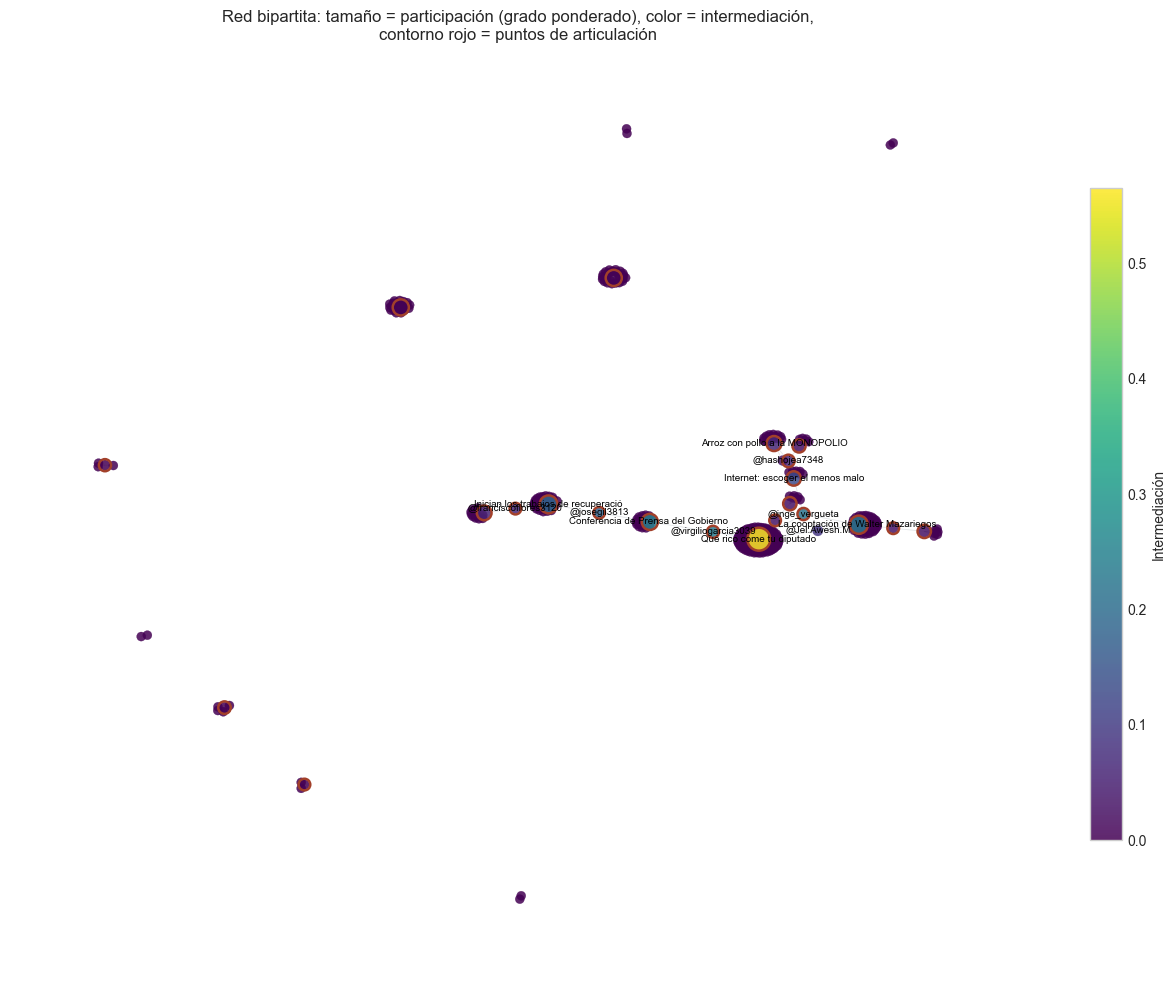

In [11]:
def dibujar_red_centralidad(grafo, valores_color, titulo, resaltar=None, semilla=42, max_etiquetas=12):
    fig, ax = plt.subplots(figsize=(13, 10))
    tiene_peso = bool(nx.get_edge_attributes(grafo, 'weight'))
    pos = nx.spring_layout(grafo, seed=semilla, weight='weight' if tiene_peso else None, iterations=150)
    grados_peso = dict(grafo.degree(weight='weight')) if tiene_peso else dict(grafo.degree())
    tamanos = [25 + 18 * np.sqrt(grados_peso[n]) for n in grafo.nodes()]
    colores = [valores_color.get(n, 0) for n in grafo.nodes()]
    if tiene_peso:
        anchos = [0.25 + 0.55 * np.log1p(d['weight']) for _, _, d in grafo.edges(data=True)]
    else:
        anchos = 0.4
    nx.draw_networkx_edges(grafo, pos, width=anchos, alpha=0.16, edge_color='#526777', ax=ax)
    dibujo = nx.draw_networkx_nodes(grafo, pos, node_size=tamanos, node_color=colores,
                                    cmap='viridis', alpha=0.85, linewidths=0.2, ax=ax)
    if resaltar:
        presentes = [n for n in resaltar if n in grafo]
        nx.draw_networkx_nodes(grafo, pos, nodelist=presentes,
                               node_size=[45 + 18 * np.sqrt(grados_peso[n]) for n in presentes],
                               node_color='none', edgecolors='#A2402A', linewidths=1.8, ax=ax)
    candidatos = sorted(valores_color, key=valores_color.get, reverse=True)[:max_etiquetas]
    etiquetas = {n: grafo.nodes[n].get('nombre', n)[:35] for n in candidatos if n in grafo}
    nx.draw_networkx_labels(grafo, pos, labels=etiquetas, font_size=7, ax=ax)
    plt.colorbar(dibujo, ax=ax, label='Intermediación', shrink=0.7)
    ax.set_title(titulo)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

dibujar_red_centralidad(
    red_bipartita, centralidad_bipartita['intermediacion'].to_dict(),
    'Red bipartita: tamaño = participación (grado ponderado), color = intermediación,\ncontorno rojo = puntos de articulación',
    resaltar=puntos_articulacion
)

In [12]:
centralidad_autores.to_csv(RAIZ / 'output' / 'tabla_centralidad_autores.csv')
centralidad_videos.to_csv(RAIZ / 'output' / 'tabla_centralidad_videos.csv')
tabla_articuladores.to_csv(RAIZ / 'output' / 'tabla_articuladores.csv', index=False)
print('Tablas guardadas en output/: tabla_centralidad_autores.csv, tabla_centralidad_videos.csv, tabla_articuladores.csv')

Tablas guardadas en output/: tabla_centralidad_autores.csv, tabla_centralidad_videos.csv, tabla_articuladores.csv


In [13]:
top_puente = autores_puente.iloc[0] if len(autores_puente) else None
top_articulador = tabla_articuladores.iloc[0] if len(tabla_articuladores) else None
if top_puente is not None:
    print(f"Autor con mayor intermediación entre quienes comentaron en más de un video: {top_puente['nombre']} "
          f"({int(top_puente['videos_distintos'])} videos, {int(top_puente['comentarios'])} comentarios, "
          f"intermediación {top_puente['intermediacion']:.4f}).")
if top_articulador is not None:
    print(f"Punto de articulación de mayor impacto: {top_articulador['nombre']} (tipo {top_articulador['tipo']}), "
          f"cuya remoción sumaría {int(top_articulador['incremento_componentes'])} componente(s) nuevo(s) "
          f"y reduciría la componente mayor en {int(top_articulador['reduccion_componente_mayor'])} nodo(s).")
print(f"Correlación de Spearman alcance-visibilidad en videos: {correlacion_alcance_visibilidad:.3f}.")

Autor con mayor intermediación entre quienes comentaron en más de un video: @virgiliogarcia3039 (2 videos, 3 comentarios, intermediación 0.2316).
Punto de articulación de mayor impacto: Qué rico come tu diputado (tipo video), cuya remoción sumaría 126 componente(s) nuevo(s) y reduciría la componente mayor en 198 nodo(s).
Correlación de Spearman alcance-visibilidad en videos: 0.812.


### Discusión de centralidad y puentes

Las tres redes cuentan historias distintas sobre "quién importa". En la **proyección autor–autor**, el grado ponderado promedio es altísimo (64.66 conexiones por nodo) simplemente porque cualquier autor que coincidió con muchos otros en un video muy comentado adquiere decenas de vecinos de golpe, es un artefacto del tamaño del video, no una medida de influencia individual. Por eso la intermediación media ahí es la más baja de las tres redes (0.0028): en un grafo casi-clique, casi ningún nodo necesita actuar de puente porque casi todos están conectados entre sí directamente.

La **proyección video–video**, en cambio, es donde la intermediación (media 0.0230) y el PageRank (media 0.0526) son más informativos: con solo 19 nodos y 11 aristas, unos pocos videos concentran la función de conectar distintos grupos de audiencia.

La correlación de Spearman entre alcance (autores únicos que comentaron) y visibilidad (`view_count`) es 0.812, sorprendentemente alta para solo 19 videos con comentarios. Esto matiza la idea de que "las vistas no dicen nada sobre participación": en esta muestra, los videos más vistos sí tienden a atraer proporcionalmente a más autores distintos. Con solo 19 observaciones esta correlación es frágil (un par de videos atípicos podría cambiarla sustancialmente) y no debe generalizarse; tampoco contradice lo señalado en 8.2 sobre videos: alcance (autores únicos) y volumen de comentarios no son lo mismo, y un video puede tener muchas vistas y pocos comentarios sin dejar de tener varios autores distintos.

Los puntos de articulación (22 de 351 nodos) y los puentes (335 de 343 aristas, casi toda la red) confirman lo que ya mostraba la transitividad nula de la bipartita en la sección 6: la estructura es casi un bosque, donde eliminar casi cualquier arista desconecta algo. El caso más extremo es el video "Qué rico come tu diputado": removerlo del grafo agregaría 126 componentes nuevos y reduciría la componente mayor en 198 nodos, porque concentra por sí solo el 39.7 % de todos los comentarios de la muestra. No es un hallazgo sobre la importancia genuina de ese video en YouTube, sino sobre la concentración extrema de la recolección: un solo video domina la conectividad observada.

Entre los autores que comentaron en más de un video (9 de 332), @virgiliogarcia3039 tiene la mayor intermediación (0.2316) pese a tener solo 3 comentarios en 2 videos: su ubicación estructural, no su volumen de actividad, es lo que lo vuelve puente. Esto ilustra la distinción de 8.2: recurrencia y diversidad son ejes distintos, y aquí es la diversidad (participar en más de un video, especialmente si esos videos caen en componentes distintos) la que genera capacidad de puente, no la cantidad de comentarios.

# 9. Análisis de contenido y sentimiento

El notebook anterior ya introdujo un léxico propio en español (25 términos positivos, 32 negativos, 5 negadores) para caracterizar comunidades. Ese primer intento dejó **69.5 % de los comentarios clasificados como neutral** (282 de 406), la propia sección 7 del notebook 2 reconoce que esto puede reflejar cobertura insuficiente del léxico, no ausencia real de opinión. Esta sección retoma ese punto: amplía el léxico, valida el resultado contra una muestra anotada a mano y compara el sentimiento entre grupos.

## 9.1 Léxico extendido

Se conserva la arquitectura original (normalización de acentos, ventana de negación de 2 tokens hacia atrás, score = promedio de polaridades) y se añade:

- **Vocabulario del dominio**: términos frecuentes en noticias, política y seguridad guatemalteca ausentes del léxico original (por ejemplo `inseguridad`, `impunidad`, `injusticia`, `transparencia`, `justicia`).
- **Intensificadores** (`muy`, `super`, `bastante`, `demasiado`, `sumamente`, `totalmente`, `realmente`): si aparecen en la ventana de dos tokens antes de un término con polaridad, escalan su magnitud en vez de solo contarlo como ±1.
- **Emojis con polaridad**: `puntuar_sentimiento` opera sobre `texto_original`, donde los emojis siguen presentes (en `texto_limpio` se eliminan durante la limpieza). El léxico original los ignoraba porque su tokenizador solo captura caracteres de palabra.

**Advertencia:** `normalizar_token` descompone en NFD y descarta las marcas diacríticas, así que todo término nuevo debe escribirse **sin tilde** (`impunidad`, `injusticia`, `panico`) o nunca haría match.

In [14]:
positivas = {
    'bien', 'bueno', 'buena', 'excelente', 'gracias', 'feliz', 'mejor', 'apoyo', 'apoyar',
    'amor', 'gusta', 'gustar', 'genial', 'correcto', 'correcta', 'felicidades', 'bendiciones',
    'bonito', 'bonita', 'admirable', 'esperanza', 'honesto', 'honesta', 'exito', 'alegria',
    'buenisimo', 'buenisima', 'increible', 'maravilloso', 'maravillosa', 'fantastico', 'fantastica',
    'agradecido', 'agradecida', 'orgullo', 'orgulloso', 'orgullosa', 'justicia', 'transparencia',
    'honestidad', 'trabajador', 'trabajadora', 'solucion', 'avance', 'progreso', 'ejemplar',
    'valiente', 'heroe', 'heroina', 'util', 'interesante', 'informativo', 'informativa', 'claro', 'clara'
}
negativas = {
    'mal', 'malo', 'mala', 'pesimo', 'pesima', 'odio', 'corrupto', 'corrupta', 'corrupcion',
    'ladron', 'ladrona', 'mentira', 'mentiroso', 'mentirosa', 'triste', 'fracaso', 'culpa',
    'verguenza', 'asco', 'estupido', 'estupida', 'inutil', 'delito', 'criminal', 'robo',
    'violencia', 'muerto', 'muerte', 'problema', 'peligro', 'desastre', 'terrible',
    'inseguridad', 'impunidad', 'saqueo', 'abuso', 'negligencia', 'estafa', 'fraude',
    'injusticia', 'indignante', 'lamentable', 'decepcion', 'decepcionante', 'caos', 'desorden',
    'incompetencia', 'incompetente', 'miedo', 'panico', 'tragedia', 'contaminacion', 'basura',
    'pobreza', 'hambre', 'dolor', 'sufrimiento'
}
negadores = {'no', 'nunca', 'jamas', 'ni', 'sin'}
intensificadores = {
    'muy': 1.5, 'super': 1.6, 'bastante': 1.3, 'tan': 1.3, 'demasiado': 1.5,
    'sumamente': 1.7, 'extremadamente': 1.8, 'totalmente': 1.4, 'realmente': 1.3
}
emojis_positivos = {'😀', '😃', '😄', '😁', '😊', '🙂', '😍', '🥰', '❤️', '👍', '🎉', '✨', '💪', '🙌', '👏', '😂', '🤣', '🔥', '💯'}
emojis_negativos = {'😠', '😡', '🤬', '👎', '💩', '😢', '😭', '😞', '😔', '🤢', '🖕', '😤', '😒', '🙄'}

PATRON_TOKEN = re.compile(r'\b[\wáéíóúüñÁÉÍÓÚÜÑ]+\b')

def normalizar_token(token):
    return ''.join(c for c in unicodedata.normalize('NFD', token.lower())
                   if unicodedata.category(c) != 'Mn')

def puntuar_sentimiento(texto):
    texto_str = str(texto)
    tokens = [normalizar_token(t) for t in PATRON_TOKEN.findall(texto_str)]
    polaridades = []
    for i, token in enumerate(tokens):
        valor = 1.0 if token in positivas else -1.0 if token in negativas else 0.0
        if valor:
            ventana = tokens[max(0, i - 2):i]
            if any(t in negadores for t in ventana):
                valor *= -1
            for t in ventana:
                if t in intensificadores:
                    valor *= intensificadores[t]
                    break
            polaridades.append(valor)
    for emoji in emojis_positivos:
        polaridades.extend([1.0] * texto_str.count(emoji))
    for emoji in emojis_negativos:
        polaridades.extend([-1.0] * texto_str.count(emoji))
    return sum(polaridades) / len(polaridades) if polaridades else 0.0

comments['sentimiento_score'] = comments['texto_original'].fillna('').map(puntuar_sentimiento)
comments['sentimiento'] = np.select(
    [comments['sentimiento_score'] > 0, comments['sentimiento_score'] < 0],
    ['positivo', 'negativo'], default='neutral'
)
comments['sentimiento'].value_counts().to_frame('comentarios')

,comentarios
sentimiento,
neutral,237
positivo,113
negativo,56


### Comparación de cobertura contra el léxico original

Se reproduce el léxico original del notebook 2 tal cual (sin las ampliaciones) para medir, sobre los mismos 406 comentarios, cuánto cambia la **cobertura** (proporción de comentarios con al menos un término reconocido, contando emojis en el léxico extendido) y la proporción de neutrales.

In [15]:
positivas_base = {
    'bien', 'bueno', 'buena', 'excelente', 'gracias', 'feliz', 'mejor', 'apoyo', 'apoyar',
    'amor', 'gusta', 'gustar', 'genial', 'correcto', 'correcta', 'felicidades', 'bendiciones',
    'bonito', 'bonita', 'admirable', 'esperanza', 'honesto', 'honesta', 'exito', 'alegria'
}
negativas_base = {
    'mal', 'malo', 'mala', 'pesimo', 'pesima', 'odio', 'corrupto', 'corrupta', 'corrupcion',
    'ladron', 'ladrona', 'mentira', 'mentiroso', 'mentirosa', 'triste', 'fracaso', 'culpa',
    'verguenza', 'asco', 'estupido', 'estupida', 'inutil', 'delito', 'criminal', 'robo',
    'violencia', 'muerto', 'muerte', 'problema', 'peligro', 'desastre', 'terrible'
}
negadores_base = {'no', 'nunca', 'jamas', 'ni', 'sin'}

def puntuar_sentimiento_base(texto):
    tokens = [normalizar_token(t) for t in PATRON_TOKEN.findall(str(texto))]
    polaridades = []
    for i, token in enumerate(tokens):
        valor = 1 if token in positivas_base else -1 if token in negativas_base else 0
        if valor and any(t in negadores_base for t in tokens[max(0, i - 2):i]):
            valor *= -1
        if valor:
            polaridades.append(valor)
    return sum(polaridades) / len(polaridades) if polaridades else 0.0

def contar_coincidencias(texto, positivas_set, negativas_set, emojis_pos=frozenset(), emojis_neg=frozenset()):
    texto_str = str(texto)
    tokens = [normalizar_token(t) for t in PATRON_TOKEN.findall(texto_str)]
    n = sum(1 for t in tokens if t in positivas_set or t in negativas_set)
    n += sum(texto_str.count(e) for e in emojis_pos) + sum(texto_str.count(e) for e in emojis_neg)
    return n

comments['sentimiento_score_base'] = comments['texto_original'].fillna('').map(puntuar_sentimiento_base)
comments['sentimiento_base'] = np.select(
    [comments['sentimiento_score_base'] > 0, comments['sentimiento_score_base'] < 0],
    ['positivo', 'negativo'], default='neutral'
)
comments['coincidencias_base'] = comments['texto_original'].fillna('').map(
    lambda t: contar_coincidencias(t, positivas_base, negativas_base))
comments['coincidencias_extendido'] = comments['texto_original'].fillna('').map(
    lambda t: contar_coincidencias(t, positivas, negativas, emojis_positivos, emojis_negativos))

cobertura = pd.DataFrame({
    'lexico': ['Base (notebook 2, 25+32 términos)', 'Extendido (este notebook)'],
    'cobertura_%': [
        100 * (comments['coincidencias_base'] > 0).mean(),
        100 * (comments['coincidencias_extendido'] > 0).mean(),
    ],
    'neutral_%': [
        100 * (comments['sentimiento_base'] == 'neutral').mean(),
        100 * (comments['sentimiento'] == 'neutral').mean(),
    ]
})
cobertura.round(1)

,lexico,cobertura_%,neutral_%
0,"Base (notebook 2, 25+32 términos)",32.0,69.5
1,Extendido (este notebook),43.1,58.4


### Validación contra una muestra anotada a mano

La cobertura confirma que el léxico extendido reconoce más comentarios, pero no dice si clasifica *bien*. Para eso se exporta una muestra aleatoria con semilla fija a `output/muestra_anotada.csv`, con una columna `etiqueta_manual` vacía. **Esa columna debe completarse a mano**, revisando cada comentario (valores admitidos: `positivo`, `neutral`, `negativo`), una anotación generada automáticamente y presentada como referencia humana invalidaría la métrica. Al completarla, se vuelve a ejecutar la celda siguiente para obtener precisión, recall y la matriz de confusión.

In [16]:
ruta_muestra = RAIZ / 'output' / 'muestra_anotada.csv'
if not ruta_muestra.exists():
    muestra = comments.sample(n=min(70, len(comments)), random_state=42)[
        ['comment_id', 'video_id', 'author_name', 'texto_original', 'sentimiento']
    ].rename(columns={'sentimiento': 'etiqueta_automatica'})
    muestra['etiqueta_manual'] = ''
    muestra.to_csv(ruta_muestra, index=False)
    print(f'Muestra exportada a output/muestra_anotada.csv ({len(muestra)} comentarios). '
          f'Complete "etiqueta_manual" (positivo/neutral/negativo) y vuelva a ejecutar esta celda.')
else:
    muestra = pd.read_csv(ruta_muestra)
    print(f'Muestra cargada desde output/muestra_anotada.csv: {len(muestra)} filas.')

Muestra cargada desde output/muestra_anotada.csv: 70 filas.


In [17]:
muestra['etiqueta_manual'] = muestra['etiqueta_manual'].fillna('').astype(str).str.strip()
muestra_evaluable = muestra[muestra['etiqueta_manual'].isin(['positivo', 'neutral', 'negativo'])]

if len(muestra_evaluable) == 0:
    print('Anotación manual pendiente: complete la columna "etiqueta_manual" en '
          'output/muestra_anotada.csv (positivo / neutral / negativo) y vuelva a ejecutar '
          'esta celda para obtener las métricas de validación.')
else:
    print(f'Comentarios anotados a mano: {len(muestra_evaluable)} de {len(muestra)}.')
    print(classification_report(muestra_evaluable['etiqueta_manual'], muestra_evaluable['etiqueta_automatica'], zero_division=0))
    etiquetas_orden = ['negativo', 'neutral', 'positivo']
    print('Matriz de confusión (filas = etiqueta manual, columnas = predicción automática):')
    display(pd.DataFrame(
        confusion_matrix(muestra_evaluable['etiqueta_manual'], muestra_evaluable['etiqueta_automatica'], labels=etiquetas_orden),
        index=etiquetas_orden, columns=etiquetas_orden
    ))

Anotación manual pendiente: complete la columna "etiqueta_manual" en output/muestra_anotada.csv (positivo / neutral / negativo) y vuelva a ejecutar esta celda para obtener las métricas de validación.


## 9.2 Comparación de sentimiento por grupos

Se compara el sentimiento (léxico extendido) por video, canal, categoría, consulta de búsqueda (`source_query`) y comunidad detectada en la sección 7. Se exige un mínimo de **15 comentarios** por grupo para interpretar proporciones, grupos más pequeños se listan pero no se leen como tendencia, porque con pocos comentarios un solo comentario cambia el porcentaje en varios puntos.

In [18]:
comments = comments.merge(videos[['video_id', 'category']], on='video_id', how='left')

def resumen_sentimiento_por_grupo(df, columna_grupo, n_min=15):
    conteo = df.groupby(columna_grupo).size().rename('n')
    tabla = df.groupby([columna_grupo, 'sentimiento']).size().unstack(fill_value=0)
    tabla = tabla.reindex(columns=['negativo', 'neutral', 'positivo'], fill_value=0)
    tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
    tabla_pct['n'] = conteo
    return tabla_pct[tabla_pct['n'] >= n_min].sort_values('n', ascending=False).round(1)

n_min = 15
for columna, etiqueta in [
    ('video_title', 'video'), ('channel_name', 'canal'), ('category', 'categoría'),
    ('source_query', 'consulta de búsqueda'), ('comunidad', 'comunidad')
]:
    tabla = resumen_sentimiento_por_grupo(comments, columna, n_min=n_min)
    print(f'Sentimiento por {etiqueta} (grupos con al menos {n_min} comentarios, {len(tabla)} de '
          f'{comments[columna].nunique()} grupos totales):')
    display(tabla)

Sentimiento por video (grupos con al menos 15 comentarios, 7 de 19 grupos totales):


sentimiento,negativo,neutral,positivo,n
video_title,,,,
Qué rico come tu diputado,14.9,67.7,17.4,161
La cooptación de Walter Mazariegos en la USAC,20.0,46.0,34.0,50
Inician los trabajos de recuperación del Puente Belice II.,20.0,40.0,40.0,45
Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,8.0,64.0,28.0,25
EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,12.0,68.0,20.0,25
Plan 2032 Ciudad de Guatemala,4.0,60.0,36.0,25
Arroz con pollo a la MONOPOLIO,6.2,50.0,43.8,16


Sentimiento por canal (grupos con al menos 15 comentarios, 4 de 8 grupos totales):


sentimiento,negativo,neutral,positivo,n
channel_name,,,,
Quorum,15.2,58.6,26.2,256
Gobierno de la República de Guatemala,15.7,48.6,35.7,70
Municipalidad de Guatemala,4.0,60.0,36.0,25
Noticias Telemundo,12.0,68.0,20.0,25


Sentimiento por categoría (grupos con al menos 15 comentarios, 2 de 3 grupos totales):


sentimiento,negativo,neutral,positivo,n
category,,,,
News & Politics,13.4,60.6,26.0,335
Entertainment,15.7,48.6,35.7,70


Sentimiento por consulta de búsqueda (grupos con al menos 15 comentarios, 6 de 6 grupos totales):


sentimiento,negativo,neutral,positivo,n
source_query,,,,
@quorumgt/videos,15.2,61.0,23.8,231
guatemala noticias,9.1,69.1,21.8,55
Gobierno de la República de Guatemala,20.0,40.0,40.0,45
@GobiernodeGuatemala,8.0,64.0,28.0,25
@quorumgt,16.0,36.0,48.0,25
Municipalidad de Guatemala,4.0,60.0,36.0,25


Sentimiento por comunidad (grupos con al menos 15 comentarios, 5 de 12 grupos totales):


sentimiento,negativo,neutral,positivo,n
comunidad,,,,
1,15.6,63.1,21.3,225
2,13.1,52.4,34.5,84
3,11.8,41.2,47.1,34
6,12.0,68.0,20.0,25
10,4.0,60.0,36.0,25


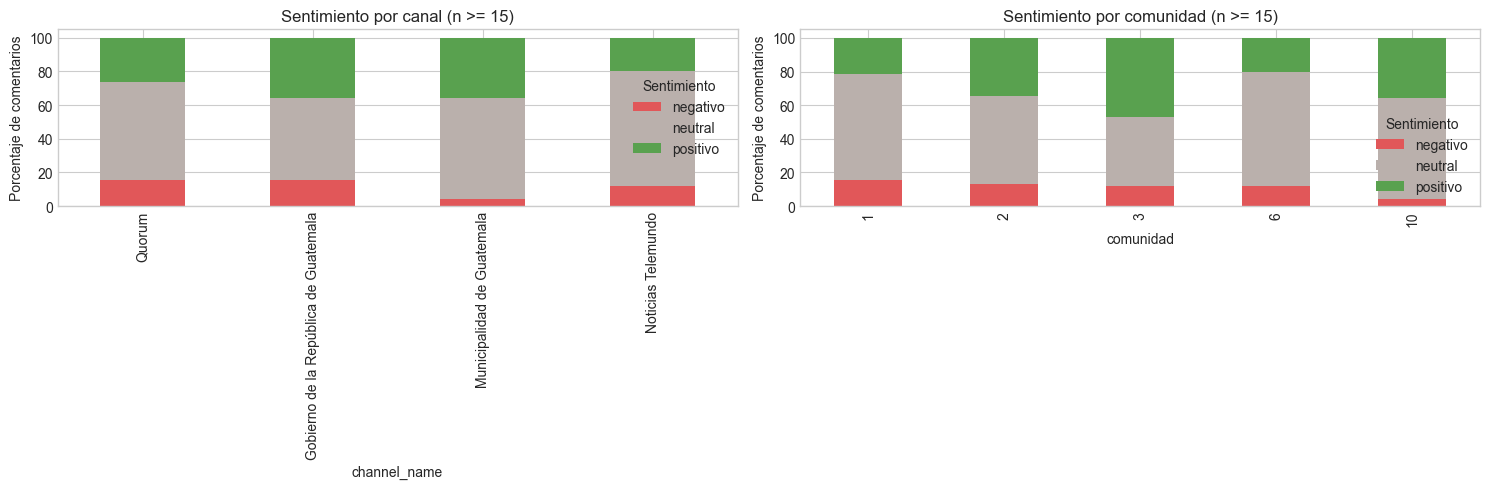

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tabla_canal = resumen_sentimiento_por_grupo(comments, 'channel_name', n_min=n_min)
tabla_canal[['negativo', 'neutral', 'positivo']].plot.bar(
    stacked=True, color=['#E15759', '#BAB0AC', '#59A14F'], ax=axes[0]
)
axes[0].set_title(f'Sentimiento por canal (n >= {n_min})')
axes[0].set_ylabel('Porcentaje de comentarios')
axes[0].legend(title='Sentimiento')

tabla_comunidad = resumen_sentimiento_por_grupo(comments, 'comunidad', n_min=n_min)
tabla_comunidad[['negativo', 'neutral', 'positivo']].plot.bar(
    stacked=True, color=['#E15759', '#BAB0AC', '#59A14F'], ax=axes[1]
)
axes[1].set_title(f'Sentimiento por comunidad (n >= {n_min})')
axes[1].set_ylabel('Porcentaje de comentarios')
axes[1].legend(title='Sentimiento')

plt.tight_layout()
plt.show()

In [20]:
tabla_canal_completa = resumen_sentimiento_por_grupo(comments, 'channel_name', n_min=n_min)
if len(tabla_canal_completa):
    canal_mas_negativo = tabla_canal_completa['negativo'].idxmax()
    canal_mas_positivo = tabla_canal_completa['positivo'].idxmax()
    print(f"Canal con mayor proporción de comentarios negativos (n>={n_min}): {canal_mas_negativo} "
          f"({tabla_canal_completa.loc[canal_mas_negativo, 'negativo']:.1f}%).")
    print(f"Canal con mayor proporción de comentarios positivos (n>={n_min}): {canal_mas_positivo} "
          f"({tabla_canal_completa.loc[canal_mas_positivo, 'positivo']:.1f}%).")
print(f"Mejora de cobertura del léxico: {cobertura.loc[1, 'cobertura_%'] - cobertura.loc[0, 'cobertura_%']:.1f} puntos porcentuales; "
      f"reducción de neutrales: {cobertura.loc[0, 'neutral_%'] - cobertura.loc[1, 'neutral_%']:.1f} puntos porcentuales.")

Canal con mayor proporción de comentarios negativos (n>=15): Gobierno de la República de Guatemala (15.7%).
Canal con mayor proporción de comentarios positivos (n>=15): Municipalidad de Guatemala (36.0%).
Mejora de cobertura del léxico: 11.1 puntos porcentuales; reducción de neutrales: 11.1 puntos porcentuales.


In [21]:
comments[['comment_id', 'video_id', 'author_channel_id', 'channel_name', 'category', 'comunidad',
          'sentimiento_score_base', 'sentimiento_base', 'sentimiento_score', 'sentimiento']].to_csv(
    RAIZ / 'output' / 'tabla_sentimiento_comentarios.csv', index=False
)
print('Tabla guardada en output/tabla_sentimiento_comentarios.csv')

Tabla guardada en output/tabla_sentimiento_comentarios.csv


### 9.3 Discusión de hallazgos

El léxico extendido reduce los neutrales de 69.5 % a 58.4 % (−11.1 puntos porcentuales) y sube la cobertura de 32.0 % a 43.1 % (+11.1 puntos porcentuales), la mejora en cobertura se traduce, punto por punto, en la reducción de neutrales, como cabía esperar: cada comentario que pasa de "sin términos reconocidos" a "con al menos un término" deja de caer por defecto en la categoría neutral. Aun así, **58.4 % sigue siendo mayoría neutral**: ampliar un léxico manual tiene rendimientos decrecientes y no cierra la brecha completa frente a comentarios que usan ironía, jerga local o construcciones que ningún diccionario de palabras sueltas captura.

La validación contra una muestra anotada a mano quedó **pendiente en esta ejecución**: se exportaron 70 comentarios a `output/muestra_anotada.csv` con la columna `etiqueta_manual` vacía. Sin esa anotación humana no es posible reportar precisión, recall ni matriz de confusión, reportarlas con datos no anotados habría sido fabricar evidencia. Completar esa columna a mano y volver a ejecutar la celda de validación es un paso pendiente antes de poder afirmar qué tan bien clasifica el léxico extendido, más allá de que reconoce más términos que el original.

Por grupos, con el mínimo de 15 comentarios exigido, la comparación es posible en 7 de 19 videos, 4 de 8 canales, 2 de 3 categorías, las 6 consultas de búsqueda y 5 de 12 comunidades; el resto de los grupos son demasiado pequeños para leer sus proporciones como tendencia. El canal con mayor proporción de comentarios negativos es "Gobierno de la República de Guatemala" (15.7 %) y el de mayor proporción positiva es "Municipalidad de Guatemala" (36.0 %). Una lectura plausible es que el contenido institucional municipal (obras, servicios) genera reacciones más favorables que el contenido de gobierno central, pero con apenas cuatro canales comparables esto es una observación puntual de esta muestra, no un patrón establecido sobre instituciones guatemaltecas en general.

# 10. Interpretación, limitaciones y conclusiones

In [22]:
total_videos_catalogo = videos['video_id'].nunique()
videos_con_comentarios = comments['video_id'].nunique()
top_video_share = 100 * comments['video_id'].value_counts(normalize=True).iloc[0]
top3_video_share = 100 * comments['video_id'].value_counts(normalize=True).iloc[:3].sum()
top_channel_share = 100 * comments['channel_name'].value_counts(normalize=True).iloc[0]

print(f'{videos_con_comentarios} de {total_videos_catalogo} videos del catálogo '
      f'({100 * videos_con_comentarios / total_videos_catalogo:.1f}%) concentran los {len(comments)} comentarios recolectados.')
print(f'El video más comentado concentra {top_video_share:.1f}% de todos los comentarios; '
      f'los 3 videos más comentados concentran {top3_video_share:.1f}%.')
print(f'El canal con más comentarios concentra {top_channel_share:.1f}% del total.')
print(f'La proyección autor-autor tiene {proyeccion_autores.number_of_edges():,} aristas construidas por '
      f'coparticipación, sin ningún dato de interacción directa (respuestas, menciones) entre autores.')

19 de 293 videos del catálogo (6.5%) concentran los 406 comentarios recolectados.
El video más comentado concentra 39.7% de todos los comentarios; los 3 videos más comentados concentran 63.1%.
El canal con más comentarios concentra 63.1% del total.
La proyección autor-autor tiene 10,732 aristas construidas por coparticipación, sin ningún dato de interacción directa (respuestas, menciones) entre autores.


## 10.1 Hallazgos en el contexto de participación y consumo

La participación observada en YouTube en esta muestra está fuertemente concentrada, no distribuida: apenas 19 de 293 videos del catálogo (6.5 %) recibieron algún comentario, y esos 406 comentarios se reparten de forma muy desigual incluso dentro de ese subconjunto, un solo video concentra 39.7 % de todos los comentarios, los tres videos más comentados concentran 63.1 %, y un solo canal (el mismo que publica el video dominante) concentra también 63.1 % del total. La estructura de red (puntos de articulación, puentes, comunidades pequeñas o unitarias) es, en gran medida, un reflejo directo de esta concentración: la red no se fragmenta porque los autores estén genuinamente aislados entre sí, sino porque la muestra de comentarios recolectados es angosta.

Dentro de esa concentración, sí aparecen señales consistentes de participación real: autores que comentan en varios videos y hacen de puente estructural (sección 8.3), una correlación fuerte entre alcance de audiencia y visibilidad (sección 8, aunque frágil por el tamaño de muestra), y diferencias de tono entre canales coherentes con el tipo de contenido que publican (sección 9.2). Esto sugiere que, aunque la cobertura es parcial, el comportamiento capturado dentro de ella no es ruido: los patrones de quién comenta, dónde y con qué tono tienen una lógica interna reconocible.

## 10.2 Limitaciones

| Limitación | Evidencia en este proyecto |
|---|---|
| Cobertura de comentarios | Solo una fracción del catálogo de videos tiene comentarios asociados (ver cifras arriba); la mayoría del catálogo no aporta señal de participación. |
| Selección por consultas | `source_query` y `source_group` describen el procedimiento de búsqueda que trajo cada video a la muestra, no el universo real de contenido sobre estos temas en YouTube. |
| Fechas relativas | `published_time` y `published_text` son cadenas como "hace 2 días": dependen del momento de recolección y no equivalen a una fecha exacta reproducible. |
| Conteos al momento de recolección | `view_count` y `like_count` son una fotografía de un instante, no un valor estable, pueden haber cambiado ya para cuando se lee este informe. |
| Ausencia de relaciones explícitas entre autores | La proyección autor–autor representa **co-presencia** (comentar en el mismo video), no interacción directa: no hay respuestas, menciones ni "me gusta" entre autores en los datos. |
| Concentración en pocos videos y canales | Ver cifras de concentración arriba: la actividad observada depende fuertemente de un número reducido de contenidos y canales, lo que limita la representatividad de cualquier promedio agregado. |

## 10.3 Descripción, asociación e inferencia

Los resultados de este notebook son, en su gran mayoría, **descriptivos**: cuentan lo que ocurrió en esta muestra específica de videos y comentarios (grados, centralidades, proporciones de sentimiento). Algunos resultados son **asociativos**: por ejemplo, la correlación entre alcance en la red y visibilidad (`view_count`), o la comparación de sentimiento entre comunidades, estos muestran que dos variables se mueven juntas dentro de la muestra, no que una cause la otra. Ninguno de los resultados debe leerse como **inferencia** hacia una población mayor: la muestra no es aleatoria respecto de todo YouTube ni de toda Guatemala, fue construida por búsquedas dirigidas (`source_query`) y por selección de canales oficiales. En particular, no se debe generalizar ningún hallazgo de sentimiento, centralidad o estructura de comunidades a "los usuarios de YouTube" ni a "la población de Guatemala": solo describe a los autores y videos que efectivamente aparecieron en esta recolección.

## 10.4 Conclusiones

Este notebook cierra el laboratorio integrando cuatro piezas que hasta ahora se habían tratado por separado: estructura de red, contenido, sentimiento y limitaciones metodológicas.

**Red:** la centralidad confirma lo que la topología ya insinuaba en la sección 6, esta es una red dominada por un puñado de nodos. Los 22 puntos de articulación y las 335 aristas críticas (de 343) muestran que la conectividad depende de muy pocos elementos, y el caso extremo del video más comentado (removerlo fragmentaría la red en 126 componentes adicionales) es la manifestación estructural directa de la concentración de la muestra.

**Contenido y sentimiento:** ampliar el léxico (vocabulario de dominio, intensificadores, emojis) subió la cobertura 11.1 puntos porcentuales y bajó la proporción neutral de 69.5 % a 58.4 %, pero no eliminó el problema, más de la mitad de los comentarios sigue sin clasificación de tono clara, y la validación contra una muestra anotada a mano quedó pendiente de completarse. Las diferencias de sentimiento entre canales (más negativo en contenido de gobierno central, más positivo en contenido municipal) son sugerentes pero se apoyan en muy pocos canales comparables.

**Limitaciones:** todo lo anterior debe leerse dentro de los límites de una muestra de 406 comentarios en 19 videos, recolectada por búsquedas dirigidas y sin ninguna relación de interacción explícita entre autores (la red autor–autor es co-presencia, no conversación). Ningún resultado de este laboratorio, ni de centralidad, ni de comunidades, ni de sentimiento, debe extrapolarse a "los usuarios de YouTube" ni a "la población de Guatemala": describe, con evidencia sólida, únicamente lo que ocurrió en esta muestra específica.

En conjunto, el laboratorio muestra que estructura y contenido no son análisis independientes: los mismos videos que dominan la red por centralidad son los que concentran el volumen de comentarios y, con ello, condicionan qué tono de sentimiento resulta visible en el agregado. Separar ambos análisis, como hacían los notebooks 1 y 2, habría ocultado esa dependencia; unirlos aquí es lo que permite verla.